In [ ]:
#discretization is the process to convert continuous data into discrete category or bins
#used for machine learning with categorical data 

#Discretization
#Data discretization is a preprocessing technique used to transform continuous or numerical data into discrete categories or bins. This process can be particularly useful for machine learning algorithms that handle categorical data more effectively than continuous data. It can also help to improve model interpretability and handle outliers more robustly.

In [2]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer

In [4]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
#impute missing values
df['age'].fillna(df['age'].median(),inplace=True)
df['fare'].fillna(df['fare'].median,inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17192\61301793.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(),inplace=True)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [8]:
#age discretization
k=KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='kmeans')#5 bins,encode ordinal,one hot phr karo strary uniform,quantile,kmeans
k.fit(df[['age']])
df['age_bin']=k.transform(df[['age']])

c:\Users\Lenovo\miniconda3\envs\python_ML\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


In [9]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_bin
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1.0
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1.0
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,1.0
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1.0


<Axes: xlabel='age', ylabel='Count'>

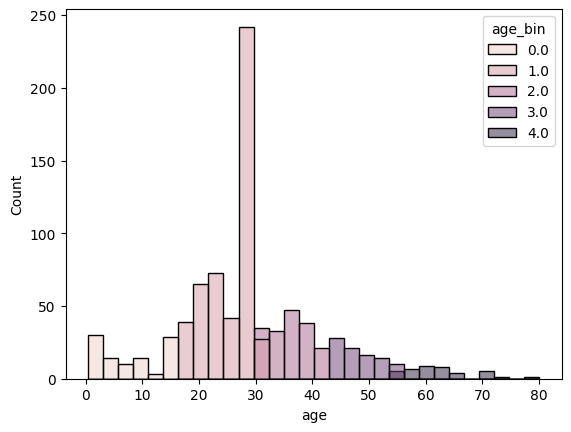

In [14]:
sns.histplot(df,x='age',hue='age_bin')

<Axes: xlabel='age', ylabel='Count'>

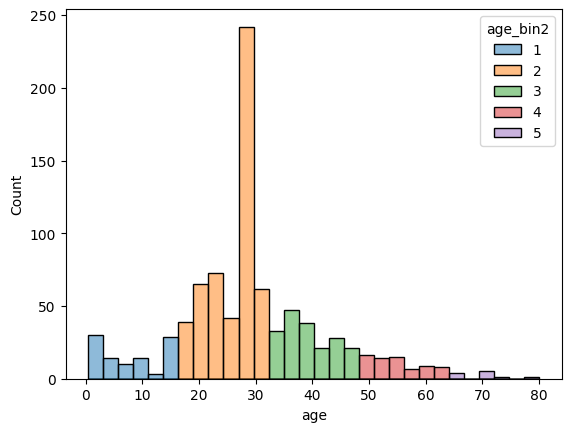

In [16]:
#pandas manual binning
df['age_bin2']=pd.cut(x=df['age'],labels=['1','2','3','4','5'],bins=5)
sns.histplot(df,x='age',hue='age_bin2')

<Axes: xlabel='age', ylabel='Count'>

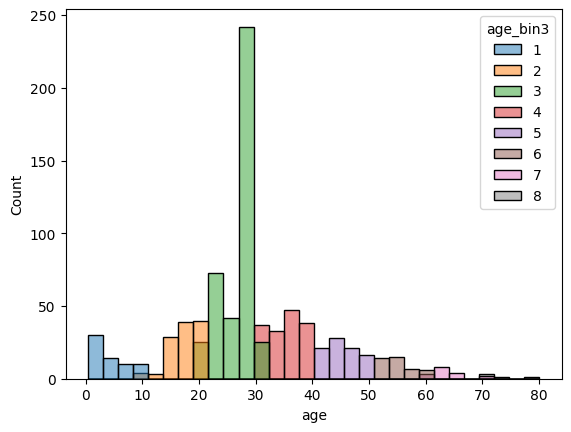

In [17]:
#or
df['age_bin3']=pd.cut(x=df['age'],bins=[0,10,20,30,40,50,60,70,80],labels=['1','2','3','4','5','6','7','8'])#ismai range humari mzri sy
sns.histplot(df,x='age',hue='age_bin3')
#pre procssing complete
#data cleaning(missing,outliers)
#data integration
#data transformation
#data reduction
#data discretization(feature encoding)